In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv("Data/synthetic_fraud_dataset1.csv")

In [6]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,...,Card_Type,Card_Age,Fraud_Label,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,TXN_33553,USER_1834,39.79,POS,14-08-2023,93213.17,Laptop,Sydney,Travel,0,...,Amex,65,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TXN_9427,USER_7875,1.19,Bank Transfer,07-06-2023,75725.25,Mobile,New York,Clothing,0,...,Mastercard,186,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TXN_199,USER_2734,28.96,Online,20-06-2023,1588.96,Tablet,Mumbai,Restaurants,0,...,Visa,226,1,NaN,33933.0,0.000000,2.0,500.48000,1.00000,1.00000
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,07-12-2023,76807.20,Tablet,New York,Clothing,0,...,Visa,76,1,NaN,16067.0,1174.140000,NaN,99998.31000,14.00000,239.00000
4,TXN_39489,USER_2014,31.28,POS,11-11-2023,92354.66,Mobile,Mumbai,Electronics,1,...,Mastercard,140,1,NaN,16067.0,99.411012,NaN,50294.06598,7.48524,119.99994


In [7]:
df.shape

(50000, 21)

In [8]:
df.columns.tolist()

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Date',
 'Account_Balance',
 'Device_Type',
 'Location',
 'Merchant_Category',
 'Previous_Fraudulent_Activity',
 'Daily_Transaction_Count',
 'Card_Type',
 'Card_Age',
 'Fraud_Label',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Date                          50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   Previous_Fraudulent_Activity  50000 non-null  int64  
 10  Daily_Transaction_Count       50000 non-null  int64  
 11  Card_Type                     50000 non-null  str    
 12  Card_Age                      50000 non-null  int64  
 13  Fraud_Label 

In [10]:
unnamed_cols = [col for col in df.columns if col.startswith("Unnamed:")]

df[unnamed_cols].dropna(how="all")

,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
2,NaN,33933.0,0.000000,2.0,500.48000,1.00000,1.00000
3,NaN,16067.0,1174.140000,NaN,99998.31000,14.00000,239.00000
4,NaN,16067.0,99.411012,NaN,50294.06598,7.48524,119.99994
5,NaN,0.0,NaN,NaN,NaN,NaN,NaN
6,NaN,1.0,NaN,NaN,NaN,NaN,NaN
7,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [11]:
unnamed_cols = [col for col in df.columns if col.startswith("Unnamed:")]

df_clean = df.drop(columns=unnamed_cols).copy()

In [12]:
df_clean.shape

(50000, 14)

In [13]:
df_clean.columns.tolist()

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Date',
 'Account_Balance',
 'Device_Type',
 'Location',
 'Merchant_Category',
 'Previous_Fraudulent_Activity',
 'Daily_Transaction_Count',
 'Card_Type',
 'Card_Age',
 'Fraud_Label']

In [14]:
df_clean.shape

(50000, 14)

In [15]:
df_clean.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Date                            0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Card_Type                       0
Card_Age                        0
Fraud_Label                     0
dtype: int64

In [16]:
df_clean.duplicated().sum()

np.int64(0)

In [17]:
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    format="%d-%m-%Y"
)

In [18]:
df_clean["Date"].dtype

dtype('<M8[us]')

In [19]:
df_clean.dtypes

Transaction_ID                             str
User_ID                                    str
Transaction_Amount                     float64
Transaction_Type                           str
Date                            datetime64[us]
Account_Balance                        float64
Device_Type                                str
Location                                   str
Merchant_Category                          str
Previous_Fraudulent_Activity             int64
Daily_Transaction_Count                  int64
Card_Type                                  str
Card_Age                                 int64
Fraud_Label                              int64
dtype: object

In [20]:
df_clean.describe(include="all")

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
count,50000,50000,50000.000000,50000,50000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000
unique,50000,8963,NaN,4,NaN,NaN,3,5,5,NaN,NaN,4,NaN,NaN
top,TXN_33553,USER_6599,NaN,POS,NaN,NaN,Tablet,Tokyo,Clothing,NaN,NaN,Mastercard,NaN,NaN
freq,1,16,NaN,12549,NaN,NaN,16779,10208,10033,NaN,NaN,12693,NaN,NaN
mean,NaN,NaN,99.411012,NaN,2023-07-02 00:46:39.360000,50294.065981,NaN,NaN,NaN,0.098400,7.485240,NaN,119.999940,0.321340
min,NaN,NaN,0.000000,NaN,2023-01-01 00:00:00,500.480000,NaN,NaN,NaN,0.000000,1.000000,NaN,1.000000,0.000000
25%,NaN,NaN,28.677500,NaN,2023-04-02 00:00:00,25355.995000,NaN,NaN,NaN,0.000000,4.000000,NaN,60.000000,0.000000
50%,NaN,NaN,69.660000,NaN,2023-07-02 00:00:00,50384.430000,NaN,NaN,NaN,0.000000,7.000000,NaN,120.000000,0.000000
75%,NaN,NaN,138.852500,NaN,2023-10-01 00:00:00,75115.135000,NaN,NaN,NaN,0.000000,11.000000,NaN,180.000000,1.000000
max,NaN,NaN,1174.140000,NaN,2023-12-31 00:00:00,99998.310000,NaN,NaN,NaN,1.000000,14.000000,NaN,239.000000,1.000000


In [21]:
df_clean.dtypes

Transaction_ID                             str
User_ID                                    str
Transaction_Amount                     float64
Transaction_Type                           str
Date                            datetime64[us]
Account_Balance                        float64
Device_Type                                str
Location                                   str
Merchant_Category                          str
Previous_Fraudulent_Activity             int64
Daily_Transaction_Count                  int64
Card_Type                                  str
Card_Age                                 int64
Fraud_Label                              int64
dtype: object

In [22]:
fraud_counts = df_clean["Fraud_Label"].value_counts()

fraud_counts

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

In [23]:
fraud_percentages = df_clean["Fraud_Label"].value_counts(normalize=True) * 100

fraud_percentages

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64

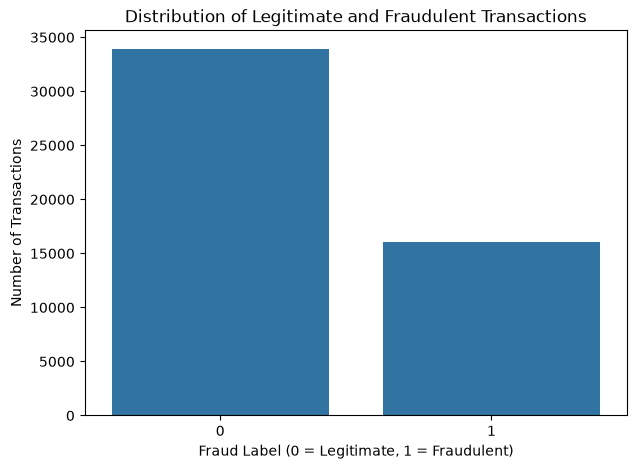

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="Fraud_Label")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Number of Transactions")

plt.show()

In [25]:
transaction_fraud_rate = (
    df_clean.groupby("Transaction_Type")["Fraud_Label"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

transaction_fraud_rate

Transaction_Type
ATM Withdrawal    32.490163
Online            32.129762
Bank Transfer     32.083199
POS               31.835206
Name: Fraud_Label, dtype: float64

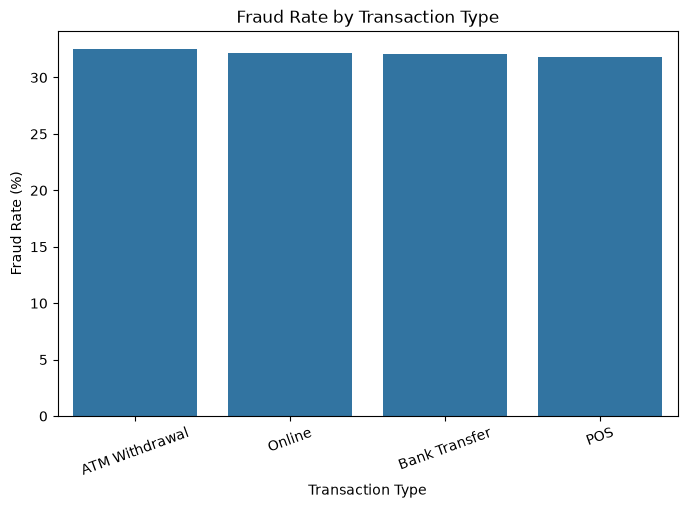

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=transaction_fraud_rate.index,
    y=transaction_fraud_rate.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [27]:
transaction_fraud_rate

Transaction_Type
ATM Withdrawal    32.490163
Online            32.129762
Bank Transfer     32.083199
POS               31.835206
Name: Fraud_Label, dtype: float64

In [28]:
merchant_fraud_rate = (
    df_clean.groupby("Merchant_Category")["Fraud_Label"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

merchant_fraud_rate

Merchant_Category
Restaurants    32.628308
Travel         32.301548
Groceries      32.108993
Electronics    31.927287
Clothing       31.705372
Name: Fraud_Label, dtype: float64

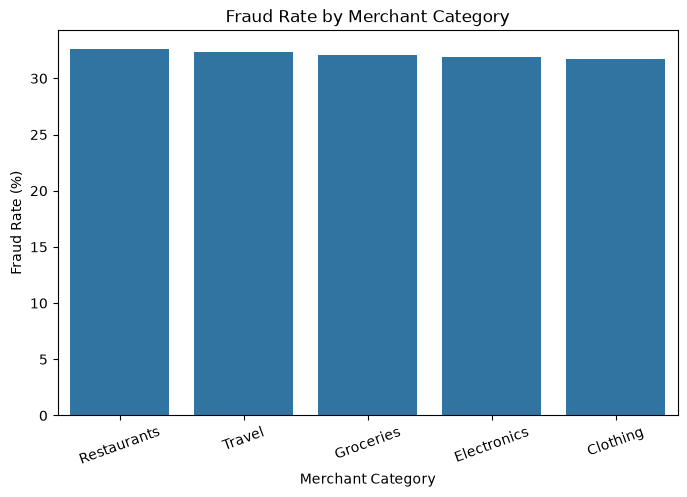

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=merchant_fraud_rate.index,
    y=merchant_fraud_rate.values
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [30]:
merchant_fraud_rate

Merchant_Category
Restaurants    32.628308
Travel         32.301548
Groceries      32.108993
Electronics    31.927287
Clothing       31.705372
Name: Fraud_Label, dtype: float64

In [31]:
previous_fraud_rate = (
    df_clean.groupby("Previous_Fraudulent_Activity")["Fraud_Label"]
    .mean()
    * 100
)

previous_fraud_rate

Previous_Fraudulent_Activity
0    32.145075
1    32.032520
Name: Fraud_Label, dtype: float64

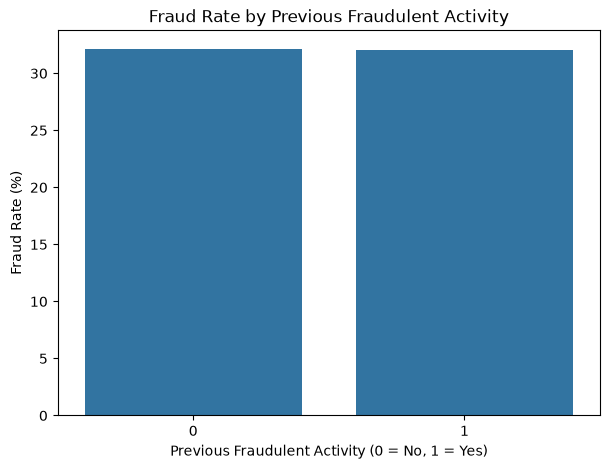

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=previous_fraud_rate.index,
    y=previous_fraud_rate.values
)

plt.title("Fraud Rate by Previous Fraudulent Activity")
plt.xlabel("Previous Fraudulent Activity (0 = No, 1 = Yes)")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [33]:
previous_fraud_rate

Previous_Fraudulent_Activity
0    32.145075
1    32.032520
Name: Fraud_Label, dtype: float64

In [34]:
df_clean.groupby("Fraud_Label")["Transaction_Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,99.281907,69.40,0.01,1174.14
1,16067,99.683678,70.12,0.00,1005.32


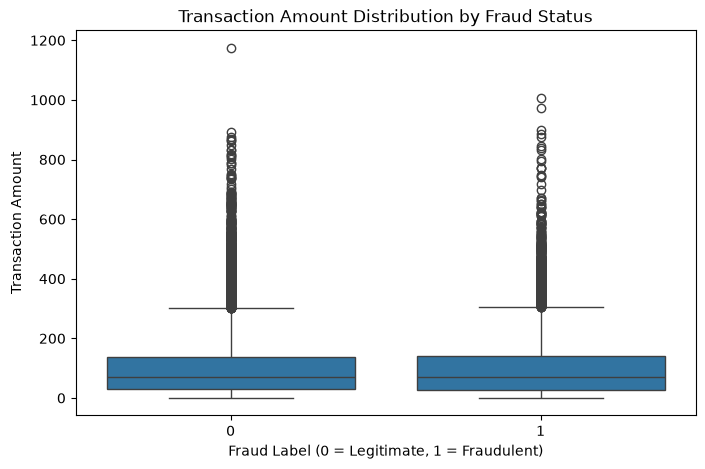

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Fraud_Label",
    y="Transaction_Amount"
)

plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Transaction Amount")

plt.show()

In [36]:
df_clean.groupby("Fraud_Label")["Account_Balance"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,50356.472852,50370.35,500.48,99998.31
1,16067,50162.264626,50415.02,503.94,99997.79


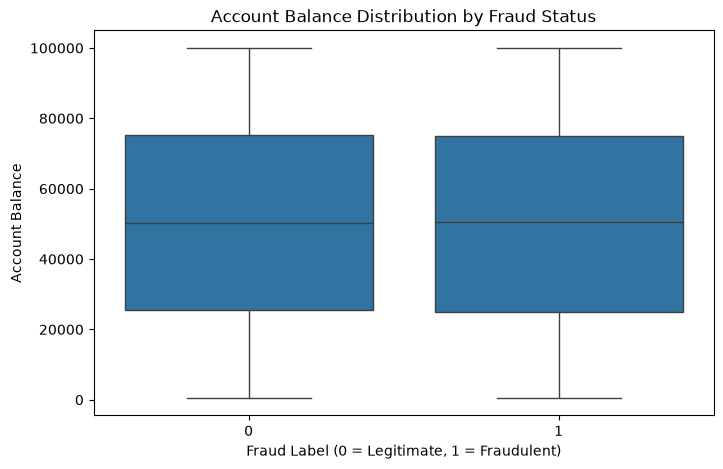

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Fraud_Label",
    y="Account_Balance"
)

plt.title("Account Balance Distribution by Fraud Status")
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Account Balance")

plt.show()

In [38]:
df_clean.groupby("Fraud_Label")["Account_Balance"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,50356.472852,50370.35,500.48,99998.31
1,16067,50162.264626,50415.02,503.94,99997.79


In [39]:
df_clean.groupby("Fraud_Label")["Daily_Transaction_Count"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,7.504877,7.0,1,14
1,16067,7.443767,7.0,1,14


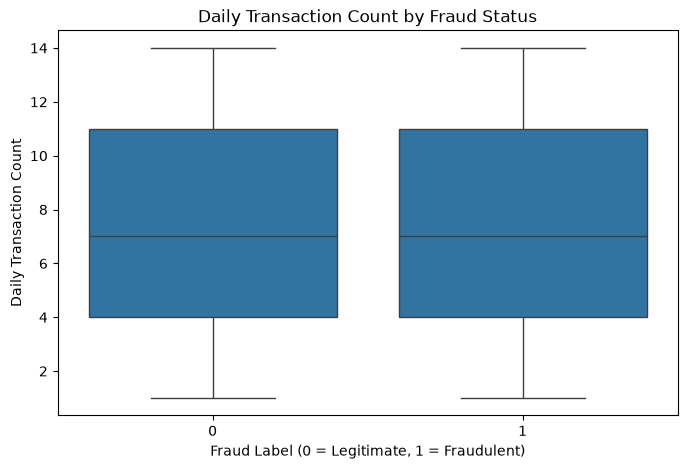

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Fraud_Label",
    y="Daily_Transaction_Count"
)

plt.title("Daily Transaction Count by Fraud Status")
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Daily Transaction Count")

plt.show()

In [41]:
df_clean.groupby("Fraud_Label")["Daily_Transaction_Count"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,7.504877,7.0,1,14
1,16067,7.443767,7.0,1,14


In [42]:
df_clean.groupby("Fraud_Label")["Card_Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,120.148056,120.0,1,239
1,16067,119.687123,119.0,1,239


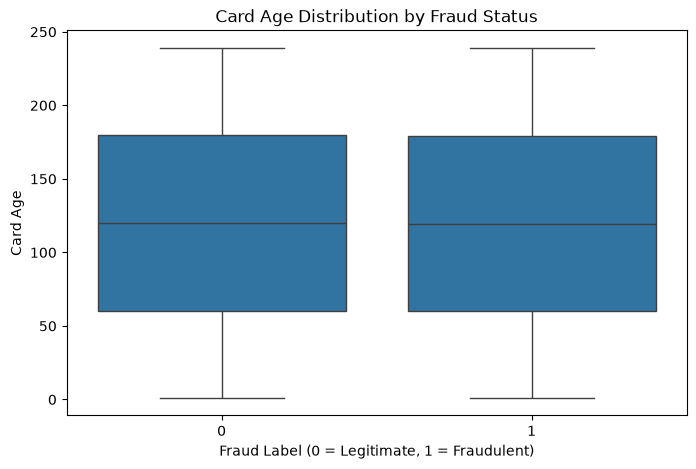

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Fraud_Label",
    y="Card_Age"
)

plt.title("Card Age Distribution by Fraud Status")
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Card Age")

plt.show()

In [44]:
df_clean.groupby("Fraud_Label")["Card_Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,120.148056,120.0,1,239
1,16067,119.687123,119.0,1,239


In [45]:
device_fraud_rate = (
    df_clean.groupby("Device_Type")["Fraud_Label"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

device_fraud_rate

Device_Type
Tablet    32.564515
Laptop    31.952234
Mobile    31.881010
Name: Fraud_Label, dtype: float64

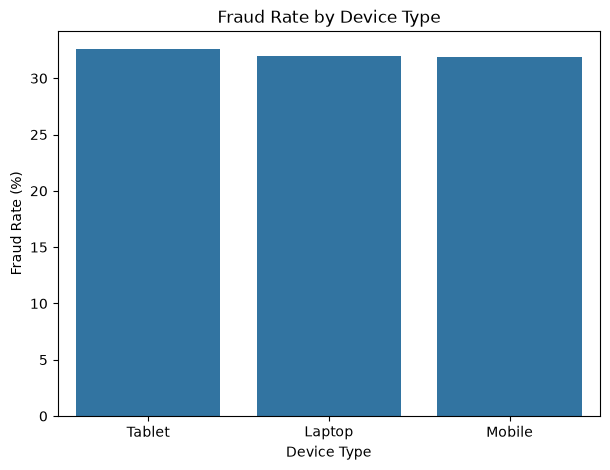

In [46]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=device_fraud_rate.index,
    y=device_fraud_rate.values
)

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [47]:
device_fraud_rate

Device_Type
Tablet    32.564515
Laptop    31.952234
Mobile    31.881010
Name: Fraud_Label, dtype: float64

In [48]:
location_fraud_rate = (
    df_clean.groupby("Location")["Fraud_Label"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

location_fraud_rate

Location
New York    32.486132
Tokyo       32.474530
Sydney      32.139263
London      31.985923
Mumbai      31.578947
Name: Fraud_Label, dtype: float64

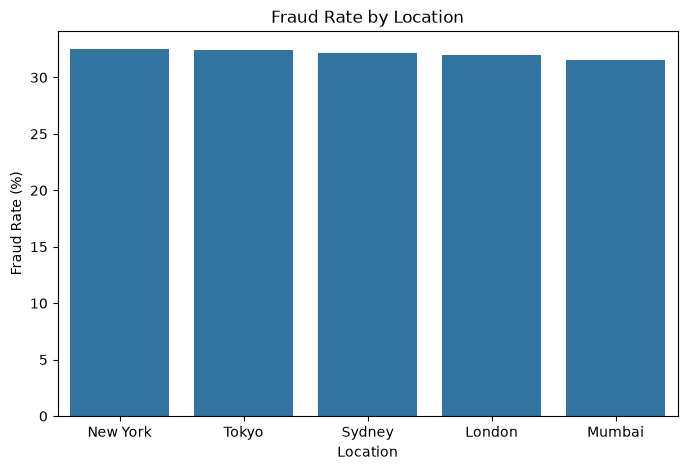

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=location_fraud_rate.index,
    y=location_fraud_rate.values
)

plt.title("Fraud Rate by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [50]:
location_fraud_rate


Location
New York    32.486132
Tokyo       32.474530
Sydney      32.139263
London      31.985923
Mumbai      31.578947
Name: Fraud_Label, dtype: float64

In [51]:
card_fraud_rate = (
    df_clean.groupby("Card_Type")["Fraud_Label"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

card_fraud_rate

Card_Type
Discover      32.495133
Amex          32.377808
Visa          31.863057
Mastercard    31.812810
Name: Fraud_Label, dtype: float64

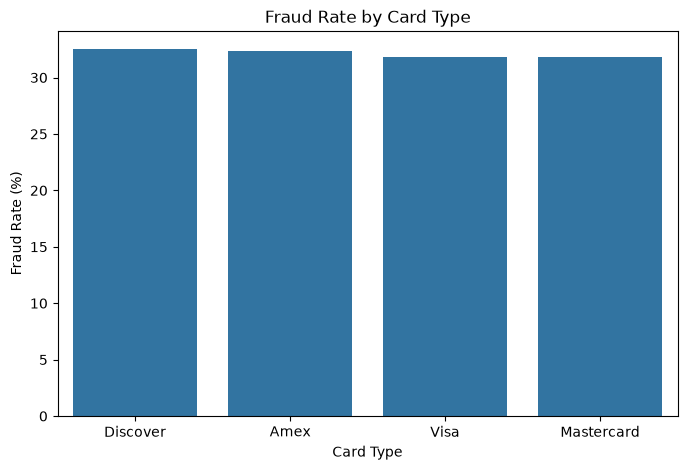

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=card_fraud_rate.index,
    y=card_fraud_rate.values
)

plt.title("Fraud Rate by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [53]:
card_fraud_rate


Card_Type
Discover      32.495133
Amex          32.377808
Visa          31.863057
Mastercard    31.812810
Name: Fraud_Label, dtype: float64

In [54]:
df_clean["Month"] = df_clean["Date"].dt.month

In [55]:
monthly_fraud_rate = (
    df_clean.groupby("Month")["Fraud_Label"]
    .mean()
    .mul(100)
)

monthly_fraud_rate

Month
1     33.094556
2     31.924161
3     31.932378
4     31.904530
5     31.595387
6     32.379808
7     32.138619
8     32.709854
9     31.196477
10    32.252642
11    31.848225
12    32.548380
Name: Fraud_Label, dtype: float64

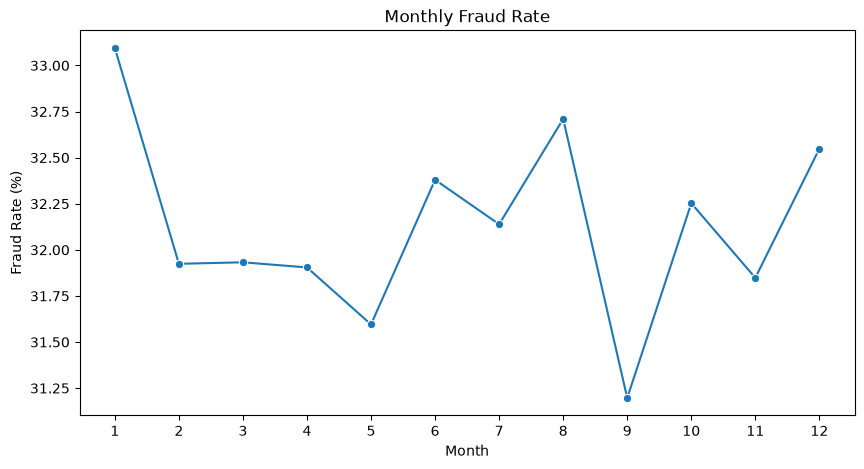

In [56]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_fraud_rate.index,
    y=monthly_fraud_rate.values,
    marker="o"
)

plt.title("Monthly Fraud Rate")
plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(1, 13))

plt.show()

In [57]:
monthly_fraud_rate

Month
1     33.094556
2     31.924161
3     31.932378
4     31.904530
5     31.595387
6     32.379808
7     32.138619
8     32.709854
9     31.196477
10    32.252642
11    31.848225
12    32.548380
Name: Fraud_Label, dtype: float64

In [58]:
df_clean["Month"] = df_clean["Date"].dt.month

In [59]:
monthly_fraud_count = (
    df_clean[df_clean["Fraud_Label"] == 1]
    .groupby("Month")
    .size()
)

monthly_fraud_count

Month
1     1386
2     1246
3     1360
4     1310
5     1315
6     1347
7     1354
8     1434
9     1275
10    1343
11    1301
12    1396
dtype: int64

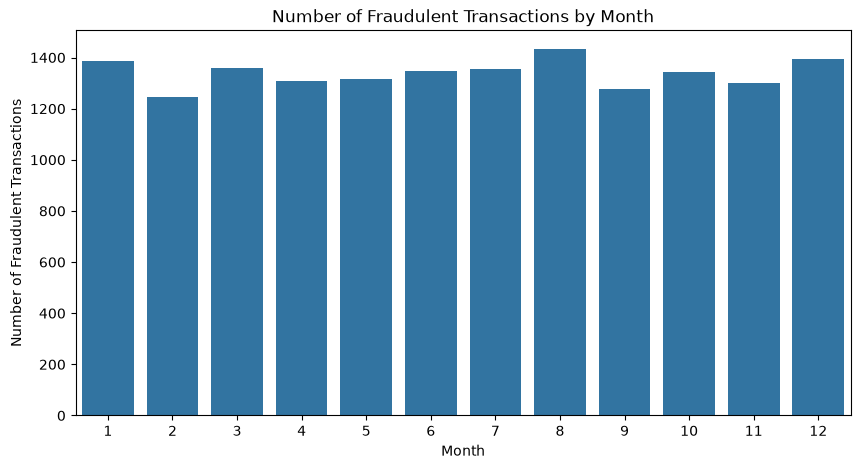

In [60]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_fraud_count.index,
    y=monthly_fraud_count.values
)

plt.title("Number of Fraudulent Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(0, 12), range(1, 13))

plt.show()

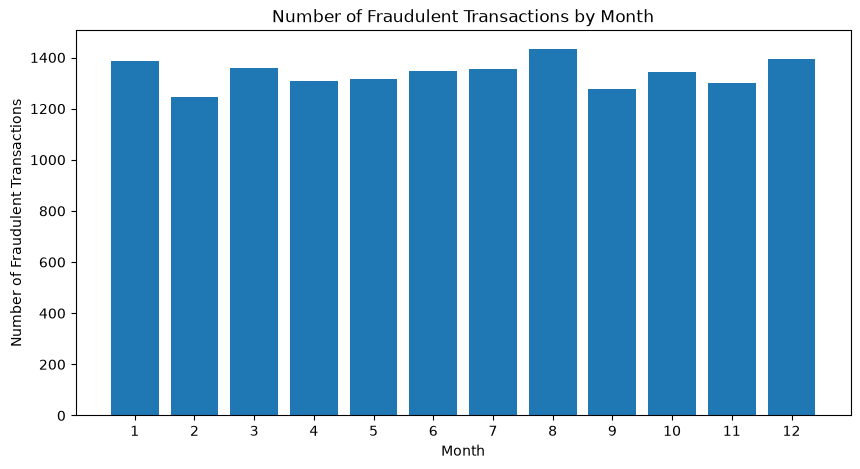

In [61]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_fraud_count.index,
    monthly_fraud_count.values
)

plt.title("Number of Fraudulent Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(1, 13))

plt.show()

In [62]:
df_clean["Day_of_Week"] = df_clean["Date"].dt.day_name()

In [63]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_fraud_rate = (
    df_clean.groupby("Day_of_Week")["Fraud_Label"]
    .mean()
    .reindex(day_order)
    .mul(100)
)

day_fraud_rate

Day_of_Week
Monday       32.342534
Tuesday      31.584869
Wednesday    31.427771
Thursday     32.696726
Friday       31.864641
Saturday     31.909066
Sunday       33.129091
Name: Fraud_Label, dtype: float64

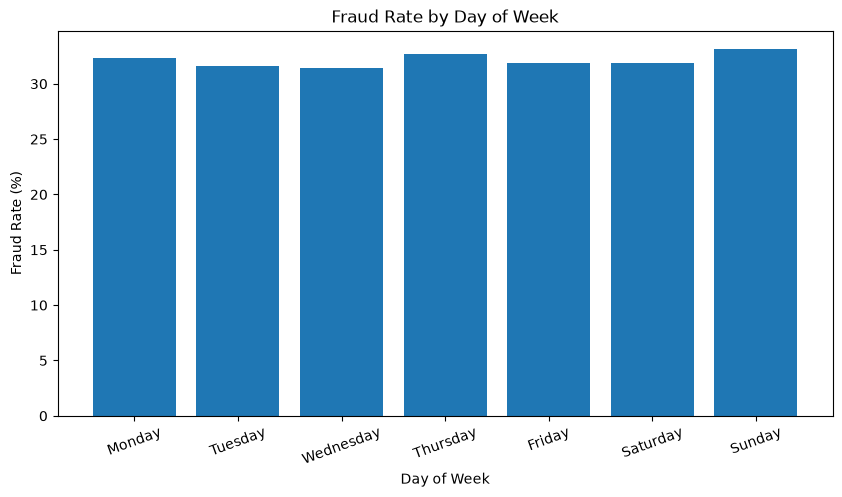

In [64]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_fraud_rate.index,
    day_fraud_rate.values
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [65]:
day_fraud_rate

Day_of_Week
Monday       32.342534
Tuesday      31.584869
Wednesday    31.427771
Thursday     32.696726
Friday       31.864641
Saturday     31.909066
Sunday       33.129091
Name: Fraud_Label, dtype: float64

In [66]:
numeric_cols = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Fraud_Label"
]

corr_matrix = df_clean[numeric_cols].corr()

corr_matrix

,Transaction_Amount,Account_Balance,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Age,Fraud_Label
Transaction_Amount,1.000000,-0.002380,0.001668,0.002149,0.002294,0.001901
Account_Balance,-0.002380,1.000000,-0.002314,0.006041,0.000717,-0.003153
Previous_Fraudulent_Activity,0.001668,-0.002314,1.000000,0.000492,-0.006713,-0.000718
Daily_Transaction_Count,0.002149,0.006041,0.000492,1.000000,-0.001516,-0.007065
Card_Age,0.002294,0.000717,-0.006713,-0.001516,1.000000,-0.003120
Fraud_Label,0.001901,-0.003153,-0.000718,-0.007065,-0.003120,1.000000


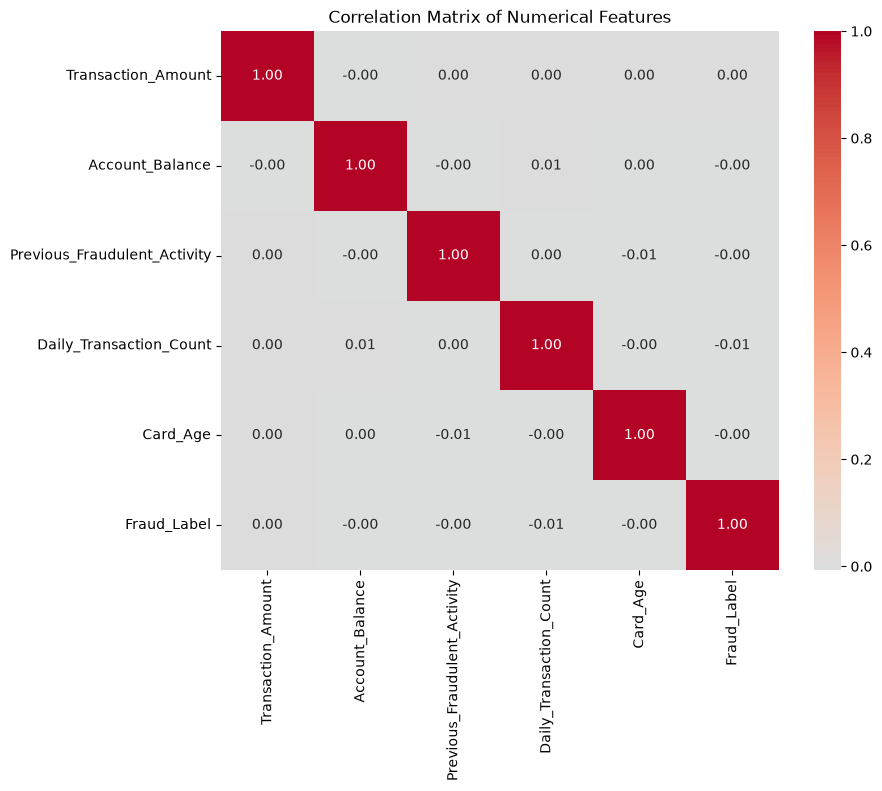

In [67]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [68]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["Day_of_Week_Number"] = df_clean["Date"].dt.dayofweek

In [69]:
df_clean[[
    "Date",
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Day_of_Week_Number"
]].head()

,Date,Year,Month,Day,Day_of_Week,Day_of_Week_Number
0,2023-08-14,2023,8,14,Monday,0
1,2023-06-07,2023,6,7,Wednesday,2
2,2023-06-20,2023,6,20,Tuesday,1
3,2023-12-07,2023,12,7,Thursday,3
4,2023-11-11,2023,11,11,Saturday,5


In [70]:
final_df = df_clean.drop(columns=["Day_of_Week"])

In [71]:
final_df.shape

(50000, 18)

In [72]:
final_df.shape

(50000, 18)

In [73]:
final_df.isnull().sum().sum()

np.int64(0)

In [74]:
final_df.duplicated().sum()

np.int64(0)

In [75]:
final_df.to_csv("financial_fraud_cleaned.csv", index=False)